In [1]:
import fluid_flow_1d_lofi as lofi
import fluid_flow_1d_hifi_eval as hifi
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
import importlib

Succesfully imported fluid_flow_1d_lofi


In [ ]:
# import fluid_flow_1d_lofi as lofi


In [ ]:
# importlib.reload(hifi)

<module 'fluid_flow_1d_hifi_eval' from '/Users/mmadhav/GitRepos/sabl/examples/Transient_Fluid_Flow_Tracer_1D/python/serverside/fluid_flow_1d_hifi_eval.py'>

In [21]:
k0_fn = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(0.1*x[0]-1,2)", degree=2), lofi.K)
k0 = lofi.fenics_convert(k0_fn, 'vector')
kt_lofi = lofi.state_solve(k0, return_type="vector", annotate=False, return_all=False)

## Finite-Difference Checks

In [22]:
h = 1.e-4
e1 = lofi.np.zeros_like(kt_lofi)
e1[1-1] = 1;
he1 = h*e1;
print("\nFinite-Difference Check for lofi.misfit_gradient:")
print((lofi.J(k0, kt_lofi+he1) - lofi.J(k0, kt_lofi))/h)
print(lofi.misfit_gradient(kt_lofi, k0)[1-1])

print("\nFinite-Difference Check for lofi.apply_misfit_hessian:")
print((lofi.misfit_gradient(kt_lofi+he1, k0) - lofi.misfit_gradient(kt_lofi, k0))/h)
print(lofi.apply_misfit_hessian(lofi.np.pad(e1, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant'), k0, kt_lofi)[-(lofi.N+1):])

print("\nFinite-Difference Check for lofi.apply_solution_operator_z_jacobian:")
fd_val = (lofi.state_solve(k0 + he1, return_type="vector", annotate=False, return_all=True) - lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True))/h;
test_val = lofi.apply_solution_operator_z_jacobian(e1, k0)
print(fd_val[-31:-20])
print(test_val[-31:-20])

print("\nVerification for lofi.apply_solution_operator_z_jacobian_transpose:")
e2 = lofi.np.zeros_like(kt_lofi); e2[2-1] = 1;
e2_padded = lofi.np.pad(e2, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant');
print(lofi.np.dot(e2_padded, lofi.apply_solution_operator_z_jacobian(e1, k0)))
print(lofi.np.dot(e1, lofi.apply_solution_operator_z_jacobian_transpose(e2_padded, k0)))


Finite-Difference Check for lofi.misfit_gradient:
288.3877037629645
288.38214820330217

Finite-Difference Check for lofi.apply_misfit_hessian:
[111.11111111  55.55555555   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]

Finite-Difference Check for lofi.apply_solution_operator_z_jacobian:
[ 3.04877630e-04  3.16814757e-04  3.28144645e-05 -5.15024245

In [3]:
h = 1.e-4
e1 = lofi.np.zeros_like(kt_lofi)
e1[1-1] = 1;
he1 = h*e1;
print("Finite-Difference Check for lofi.misfit_gradient:")
print((lofi.J(k0, kt_lofi+he1) - lofi.J(k0, kt_lofi))/h)
print(lofi.misfit_gradient(kt_lofi, k0)[1-1])

print("\nFinite-Difference Check for lofi.apply_misfit_hessian:")
print((lofi.misfit_gradient(kt_lofi+he1, k0) - lofi.misfit_gradient(kt_lofi, k0))/h)
print(lofi.apply_misfit_hessian(lofi.np.pad(e1, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant'), k0, kt_lofi)[-(lofi.N+1):])

print("\nFinite-Difference Check for lofi.apply_solution_operator_z_jacobian:")
fd_val = (lofi.state_solve(k0 + he1, return_type="vector", annotate=False, return_all=True) - lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True))/h;
test_val = lofi.apply_solution_operator_z_jacobian(e1, k0)
print(fd_val[-31:-20])
print(test_val[-31:-20])

print("\nVerification for lofi.apply_solution_operator_z_jacobian_transpose:")
e2 = lofi.np.zeros_like(kt_lofi); e2[2-1] = 1;
e2_padded = lofi.np.pad(e2, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant');
print(lofi.np.dot(e2_padded, lofi.apply_solution_operator_z_jacobian(e1, k0)))
print(lofi.np.dot(e1, lofi.apply_solution_operator_z_jacobian_transpose(e2_padded, k0)))

Finite-Difference Check for lofi.misfit_gradient:
359.9404671786033
359.93491162182573

Finite-Difference Check for lofi.apply_misfit_hessian:
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]

Finite-Difference Check for lofi.apply_solution_operator_z_jacobian:
[ 4.49712366e-03  4.56332941e-03  2.36795861e-03  7.62145951e

In [23]:
# u_timeseries_lofi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_lofi_1d")
# u_timeseries_midfi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_midfi_1d")
# u_l = lofi.Function(lofi.U)
# u_m = lofi.Function(lofi.U)
# u_timeseries_lofi.retrieve(u_l.vector(), 0.01)
# u_timeseries_midfi.retrieve(u_m.vector(), 0.01)
# plt.plot(u_l.vector()[:])
# plt.plot(u_m.vector()[:])


In [24]:
# kt_lofi_fn = lofi.state_solve(k0, return_type="function")
# k0_fn = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(0.1*x[0]-1,2)", degree=2), lofi.K)
# plt.plot(kt_hifi)
# lofi.assemble(kt_hifi_fn.dx(0) * lofi.TestFunction(lofi.K) * lofi.dx)[:]

## Analyzing Discrepancy Behavior

In [333]:
k0_1 = lofi.interpolate(lofi.Expression("5*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
k0_2 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]


In [561]:
import os
os.remove(f"{lofi.root_path}/../../data/velocity_timeseries_midfi_1d.h5")
importlib.reload(hifi)
hifi.state_solve(0*k0_1, return_type="vector", return_all=True, store_midfi=True);

[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.050

In [600]:
importlib.reload(lofi)
importlib.reload(hifi)

Succesfully imported fluid_flow_1d_lofi


<module 'fluid_flow_1d_hifi_eval' from '/Users/mmadhav/GitRepos/sabl/examples/Transient_Fluid_Flow_Tracer_1D/python/serverside/fluid_flow_1d_hifi_eval.py'>

[2.         0.84883967 0.90179379 0.86841882 0.90140841 0.93788045
 0.99777516 1.06934128 1.15454949 1.24966611 1.35384186 1.46510455
 1.58221781 1.7037327  1.82843885 1.95511622 2.08267398 2.21009676
 2.3365028  2.46109672 2.58306636 2.70127944 2.8137398  2.91669885
 3.00338171 3.06229661 3.07523537 3.01560793 2.84756227 2.5437622
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         0.87087589 0.92588301 0.89186962 0.92270713 0.95649343
 1.01333079 1.08157791 1.16324672 1.25464888 1.3549828  1.46233387
 1.57553126 1.6932008  1.81421433 1.93744246 2.06189316 2.18666119
 2.3109905  2.43423464 2.55575781 2.67462446 2.78902087 2.8952896
 2.98652589 3.05071403 3.06857015 3.011

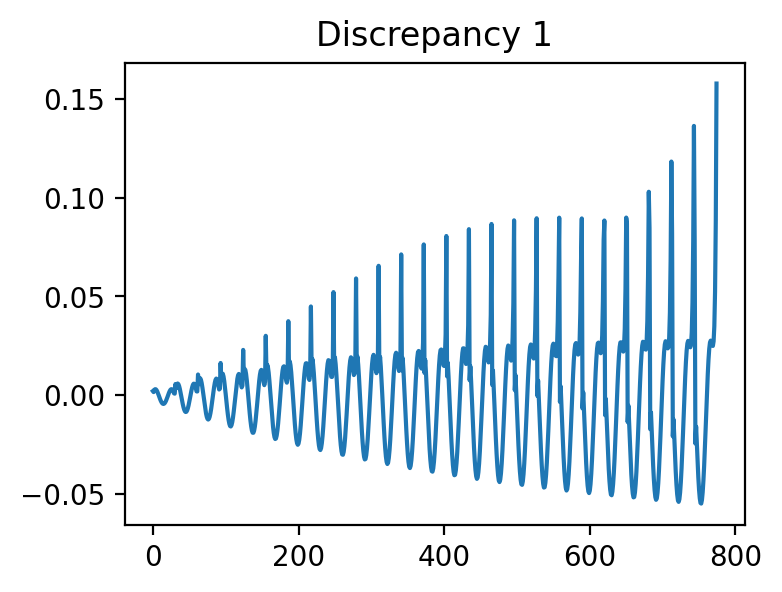

In [601]:
kt_1_lofi = lofi.state_solve(k0_1, return_type="vector", annotate=False, return_all=True)
kt_1_hifi = hifi.state_solve(k0_1, return_type="vector", return_all=True)
disc_1 = kt_1_hifi - kt_1_lofi;
plt.figure(figsize=(4, 3))
plt.plot(disc_1);
plt.title("Discrepancy 1");
print(f"Relative magnitude of discrepancy: {100*lofi.np.linalg.norm(disc_1)/lofi.np.linalg.norm(kt_1_lofi):.2f}%")

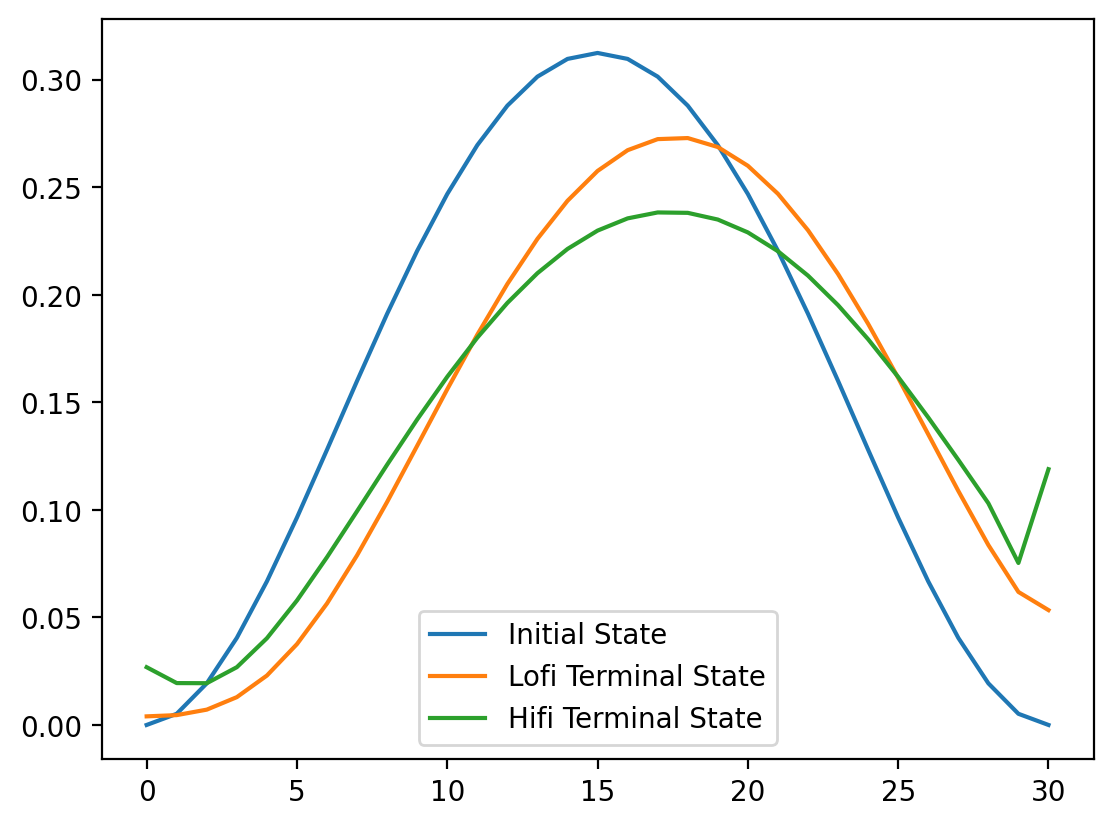

In [607]:
i=10
vertex_plot(k0_1, label='Initial State')
vertex_plot(kt_1_lofi[31*i:31*(i+1)], label='Lofi Terminal State')
vertex_plot(kt_1_hifi[31*i:31*(i+1)], label='Hifi Terminal State')
plt.legend()

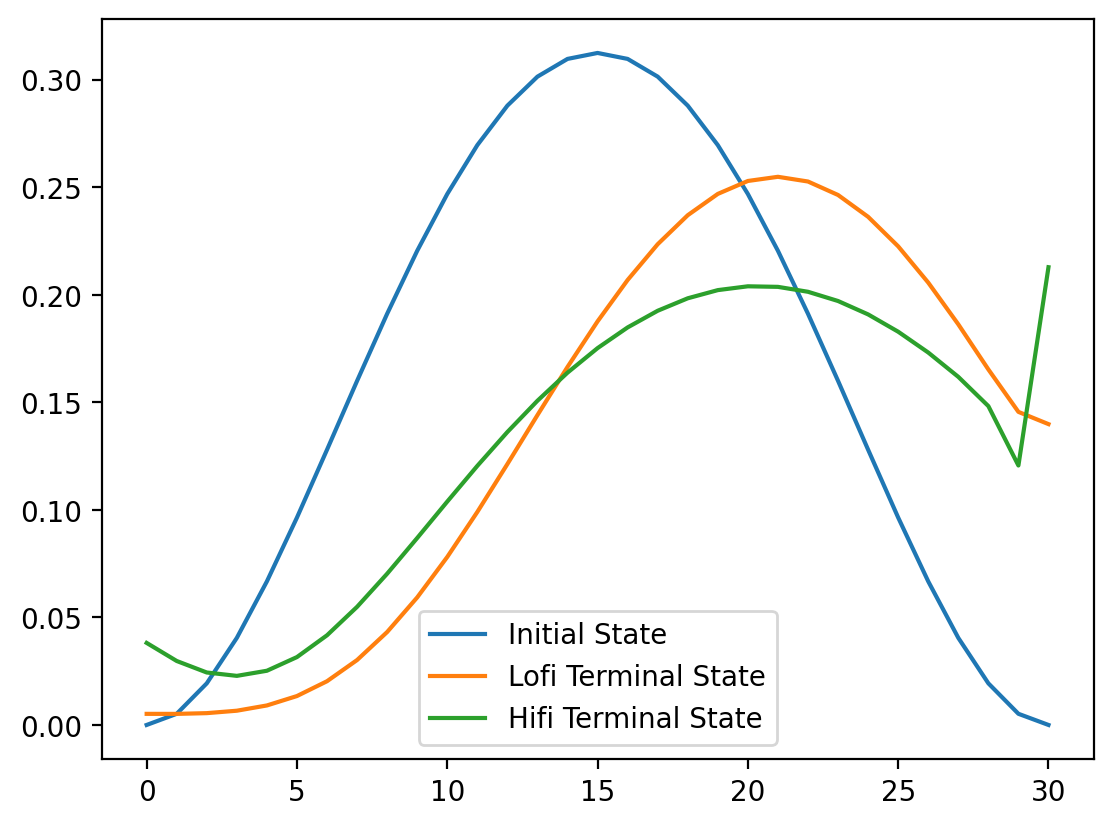

In [589]:
vertex_plot = lambda x, *args, **kwargs: plt.plot(lofi.fenics_convert(x, 'vertex', lofi.K), *args, **kwargs)
vertex_plot(k0_1, label='Initial State')
vertex_plot(kt_1_lofi[-31:], label='Lofi Terminal State')
vertex_plot(kt_1_hifi[-31:], label='Hifi Terminal State')
plt.legend()

Relative magnitude of discrepancy: 46.13%


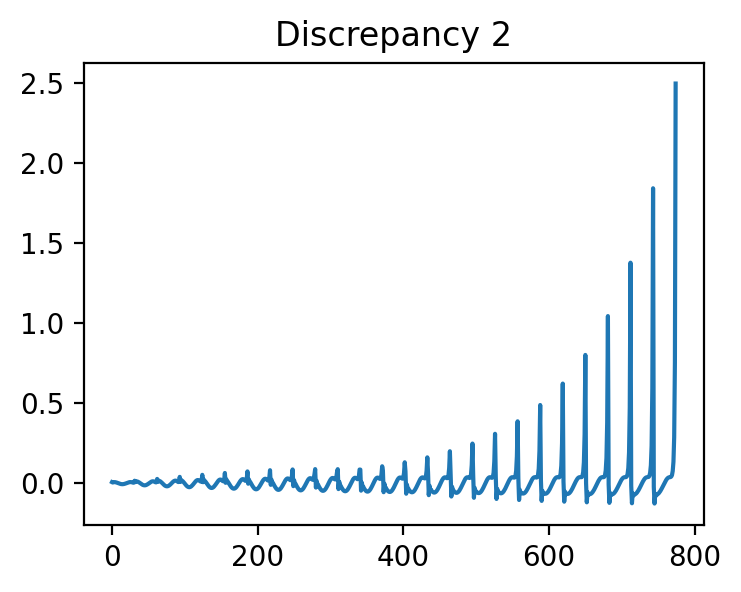

In [439]:
kt_2_lofi = lofi.state_solve(2*k0_1, return_type="vector", annotate=False, return_all=True)
kt_2_hifi = hifi.state_solve(2*k0_1, return_type="vector", return_all=True)
disc_2 = kt_2_hifi - kt_2_lofi;
plt.figure(figsize=(4, 3))
plt.plot(disc_2);
plt.title("Discrepancy 2");
print(f"Relative magnitude of discrepancy: {100*lofi.np.linalg.norm(disc_2)/lofi.np.linalg.norm(kt_2_lofi):.2f}%")

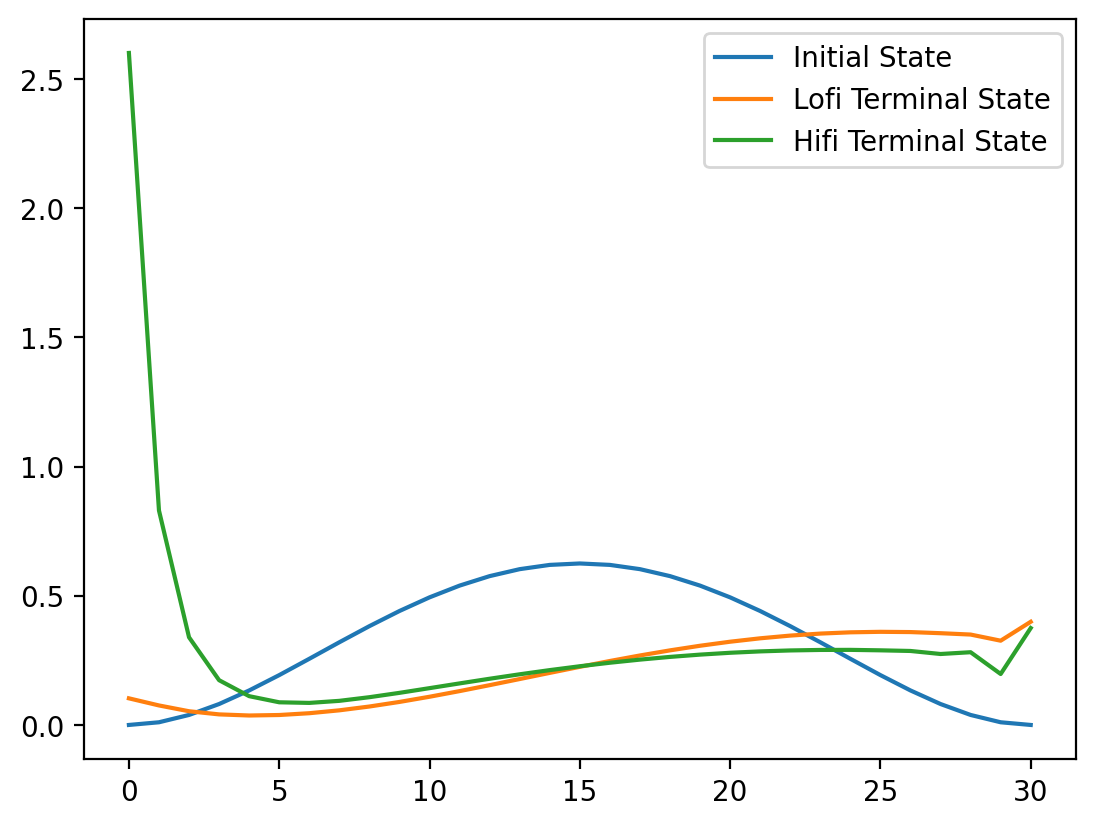

In [460]:
vertex_plot(2*k0_1, label='Initial State')
vertex_plot(kt_2_lofi[-31:], label='Lofi Terminal State')
vertex_plot(kt_2_hifi[-31:], label='Hifi Terminal State')
plt.legend()

In [430]:
# Check whether discrepancy behaves linearly
print(f"Relative diff between 2*disc_1 and disc_2: {lofi.np.linalg.norm(disc_2 - 2*disc_1)/lofi.np.linalg.norm(disc_2)*100:.2f}%")

Relative diff between 2*disc_1 and disc_2: 83.39%


In [179]:
u_timeseries = hifi.TimeSeries(f"{hifi.root_path}/../../data/velocity_timeseries_midfi_1d")


In [202]:
u_test = lofi.Function(lofi.U)
for t in range(25):
    u_timeseries.retrieve(u_test.vector(), t*0.02)
    print(u_test.vector()[:])

[1.96078431 1.928209   1.94583374 1.89560092 1.91302885 1.86298834
 1.88023412 1.83036552 1.84746046 1.79773423 1.8147012  1.76509483
 1.78195423 1.7324481  1.74921718 1.69979475 1.71648824 1.6671355
 1.68376593 1.63447104 1.65104902 1.60180201 1.61833652 1.56912896
 1.58562758 1.53645242 1.55292153 1.50377279 1.52021776 1.47109053
 1.4875158  1.4384058  1.4548152  1.40571912 1.42211559 1.37303016
 1.38941663 1.34033996 1.35671798 1.3076469  1.32401936 1.27495388
 1.29132038 1.24225568 1.25862086 1.20956084 1.22592001 1.17685405
 1.19321822 1.14415988 1.16051311 1.11143548 1.12780726 1.07874809
 1.09509285 1.04598204 1.06237948 1.01331474 1.02964186 0.98039216
 0.99689543]
[1.96078431 1.928209   1.94583374 1.89560092 1.91302885 1.86298834
 1.88023412 1.83036552 1.84746046 1.79773423 1.8147012  1.76509483
 1.78195423 1.7324481  1.74921718 1.69979475 1.71648824 1.6671355
 1.68376593 1.63447104 1.65104902 1.60180201 1.61833652 1.56912896
 1.58562758 1.53645242 1.55292153 1.50377279 1.5202

In [ ]:
# kt_lofi = lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True)
# kt_lofi_copy = lofi_copy.state_solve(k0, return_type="vector", annotate=False, return_all=True)
# kt_hifi = hifi.state_solve(k0, return_type="vector", return_all=True)
# discrep_kt = kt_hifi - kt_lofi
# plt.plot(kt_lofi[:30], label="Lofi")
# # plt.plot(kt_hifi[:30], label="Hifi")
# plt.legend()
# plt.plot(kt_lofi[-30:], label="Lofi")
# plt.plot(kt_hifi[-30:], label="Hifi")
# plt.legend()

## Additional Tests

In [70]:
# Test if "important" four functions are working.
# print(lofi.apply_solution_operator_z_jacobian_transpose(kt_in_long, k0))
# print(lofi.misfit_gradient(kt_k0, k0))
# kt_in_long = lofi.np.repeat(kt_in, 25)
# print(lofi.apply_misfit_hessian(kt_in_long, k0, kt_k0).shape)
# print(lofi.apply_rs_hessian(k0_in, k0))

(775,)


In [15]:
# k0_a = lofi.interpolate(lofi.Expression("pow(x[0], 2)", degree=1), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("1-4*pow(x[0] - 0.5, 2)", degree=2), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]
# k0_guess = lofi.interpolate(lofi.Expression("2*(0.4 < x[0] && x[0] < 0.6)", degree=1), lofi.K).vector()[:]
# k0 = k0_guess
# k0 = hifi.interpolate(hifi.Expression("x[0]*(1-x[0])*(9-10*x[0])", degree=1), hifi.C).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
kt_in = lofi.interpolate(lofi.Expression("pow(x[0], 3)", degree=2), lofi.K).vector()[:]
k0_in = lofi.interpolate(lofi.Expression("pow(x[0], 4)", degree=2), lofi.K).vector()[:]

In [22]:
# Hessian Finite Difference Check
hess_exact = lofi.apply_rs_hessian(k0_in, k0).flatten()
norm_hess_exact = lofi.np.linalg.norm(hess_exact)
dJ = lambda m: lofi.J_hat_np(m)*0 + lofi.J_hat_np.derivative(forget=None)
epsilon=0.1
hess_fd = (dJ(k0 + epsilon * k0_in) - dJ(k0 - epsilon * k0_in)) / (2 * epsilon)

print("Hessian Relative Diff: ", lofi.np.linalg.norm(hess_fd - hess_exact)/norm_hess_exact)

Hessian Relative Diff:  1.4346230451287843e-13


In [3]:
# Low-Fidelity Optimization Test 
k0_guess = lofi.fenics_convert(k0, "function", lofi.K);
k_n = lofi.state_solve(k0_guess, return_type = "function", plot_k=False, verbose=False, annotate=True);

# Set up inverse problem
J_inv = lofi.J(k0_guess, k_n)
control = lofi.Control(k0_guess)
J_hat = lofi.ReducedFunctional(J_inv, control)

# Solve Inverse Problem
with lofi.stop_verbose():
    k0_opt_lofi = lofi.minimize(J_hat, method="Newton-CG", callback=lofi.callback_call(J_hat), tol=1e-3, options={"disp": True})


Iteration  Objective Value      Gradient Norm  
---------------------------------------------
1          0.008899             0.001426       
2          0.000820             0.000074       
3          0.000759             0.000003       
4          0.000759             0.000000       
5          0.000759             0.000000       
Optimization terminated successfully.
         Current function value: 0.000759
         Iterations: 5
         Function evaluations: 5
         Gradient evaluations: 5
         Hessian evaluations: 25


In [6]:
# kt_lofi = lofi.state_solve(k0, "vector");
# u_end_lofi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_lofi.vector(), 0.1)
# print(u_end_lofi.vector()[:])
# plt.plot(u_end_lofi.vector()[:])


# kt_midfi = lofi.state_solve(k0, "vector");
# u_end_midfi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_midfi.vector(), 0.1)
# print(u_end_midfi.vector()[:])
# plt.plot(u_end_midfi.vector()[:])

In [8]:
# plt.plot(disc_k0_1)
# plt.plot(disc_k0_2)